 ## STL disease - UNet + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

### Nota important:
# He eliminat ISIC_0028189 del conjunt de train, perquè era corrupta.

2026-06-21 23:15:27.672284: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (256, 256)   # UNet usa 256x256 (propio de la arquitectura)
BATCH_SIZE  = 16
NUM_CLASSES = 7
N_FOLDS     = 5
TASK_NAME   = "disease"
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]


EPOCHS  = 60
LR_INIT = 5e-4

EXP_DIR = Path("/home/marc/MARIADELMAR_EXPERIMENTS/STL_Disease_experimentos/UNet_STL") / \
          f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_{N_FOLDS}fold"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento en: {EXP_DIR.resolve()}")

Experimento en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Disease_experimentos/UNet_STL/exp_2026-06-21_23-15_disease_5fold


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

print(f"Disease CSVs   - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")

# Path completo a las imágenes
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Arrays de etiquetas, solo disease
y_train_disease = df_train[class_cols].values.astype("float32")
y_val_disease   = df_val[class_cols].values.astype("float32")
y_test_disease  = df_test[class_cols].values.astype("float32")

# Combinar train+val para KFold
df_trainval        = pd.concat([df_train, df_val], ignore_index=True)
y_trainval_disease = np.concatenate([y_train_disease, y_val_disease], axis=0)

y_trainval_int     = np.argmax(y_trainval_disease, axis=1)
y_test_disease_int = np.argmax(y_test_disease, axis=1)

print("\n" + "="*60)
print("DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)")
print("="*60)
print("\nDisease:")
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<7} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")

# Class weights para disease
def compute_cw(y_int, n_classes):
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(n_classes),
        y=y_int,
    )
    return tf.constant(cw, dtype=tf.float32)

CW_DISEASE = compute_cw(y_trainval_int, NUM_CLASSES)

print(f"\nClass weights calculados:")
print(f"  disease: {CW_DISEASE.numpy().round(3)}")

Disease CSVs   — train: 6008  val: 2003  test: 2003

DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)

Disease:
  akiec     261  (3.3%)
  bcc       411  (5.1%)
  bkl       880  (11.0%)
  df         92  (1.1%)
  mel       890  (11.1%)
  nv       5363  (66.9%)
  vasc      114  (1.4%)

Test set fijo: 2003 imágenes

Class weights calculados:
  disease: [ 4.385  2.784  1.3   12.439  1.286  0.213 10.039]


2026-06-21 23:15:28.822214: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-21 23:15:28.857046: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-21 23:15:28.857091: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-21 23:15:28.859305: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-21 23:15:28.861281: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-21 23:15:28.861638: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [4]:
def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0        # UNet: normalización [0,1]
    # Doble target: la propia imagen (reconstrucción) y la etiqueta (clasificación)
    return img, {"reconstruction_output": img, "head_disease": y}


def load_image_aug(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = img / 255.0
    # El objetivo de reconstrucción es la misma imagen (aumentada) que entra a la red
    return img, {"reconstruction_output": img, "head_disease": y}


def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds



test_ds = make_dataset(
    df_test["filepath"].values,
    y_test_disease,
    training=False,
)

print("Sanity check: un batch del test_ds")
for imgs, targets in test_ds.take(1):
    print(f"  imagen: shape={imgs.shape}  dtype={imgs.dtype}  "
          f"min={imgs.numpy().min():.2f}  max={imgs.numpy().max():.2f}")
    print(f"  reconstruction_output: shape={targets['reconstruction_output'].shape}")
    print(f"  head_disease: shape={targets['head_disease'].shape}  (esperado: (BS, 7))")


Sanity check: un batch del test_ds
  imagen: shape=(16, 256, 256, 3)  dtype=<dtype: 'float32'>  min=0.03  max=1.00
  reconstruction_output: shape=(16, 256, 256, 3)
  head_disease: shape=(16, 7)  (esperado: (BS, 7))


In [5]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=3,
                               activation="relu", padding="same",
                               kernel_initializer="he_normal")(inputs)
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=3,
                               activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    p = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    # Upsampling 2x2
    up = tf.keras.layers.UpSampling2D(size=(2, 2))(inputs)
    x  = tf.keras.layers.Conv2D(num_filters, 2, activation="relu", padding="same",
                                kernel_initializer="he_normal")(up)
    # Skip connection: concatenar con el nivel simetrico del codificador
    x = tf.keras.layers.concatenate([skip_features, x], axis=3)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_model():
    inputs = tf.keras.layers.Input(
        shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        name="input_image"
    )

    #Codificador 
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    #Cuello de botella 
    b1 = tf.keras.layers.Conv2D(
        1024, 3, activation="relu", padding="same",
        kernel_initializer="he_normal"
    )(p4)
    b1 = tf.keras.layers.BatchNormalization()(b1)

    b1 = tf.keras.layers.Conv2D(
        1024, 3, activation="relu", padding="same",
        kernel_initializer="he_normal",
        name="bottleneck_conv"          #capa de activacion para Grad-CAM
    )(b1)
    b1 = tf.keras.layers.BatchNormalization(name="bottleneck_bn")(b1)

    #Decodificador (se entrena: reconstruye la imagen de entrada) 
    e1 = decoder_block(b1, c4, 512)
    e2 = decoder_block(e1, c3, 256)
    e3 = decoder_block(e2, c2, 128)
    e4 = decoder_block(e3, c1, 64)

    final_recon = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same",
                                         kernel_initializer="he_normal")(e4)
    final_recon = tf.keras.layers.BatchNormalization()(final_recon)
    reconstruction_output = tf.keras.layers.Conv2D(
        3, 1, activation="relu", padding="same",
        name="reconstruction_output"
    )(final_recon)   # relu, comentario Marc

    #Clasificacion (sale del cuello de botella, NO del decodificador)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(b1)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)
    out_disease = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="head_disease"
    )(shared)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[reconstruction_output, out_disease],
        name="STL_UNet_disease_autoencoder"
    )

    return model, None


_tmp_backbone, _ = build_model()
_tmp_backbone.summary()
tf.keras.utils.plot_model(
    _tmp_backbone,
    to_file=str(EXP_DIR / "00_model_architecture.png"),
    show_shapes=True, show_layer_names=True, dpi=150,
)
del _tmp_backbone
tf.keras.backend.clear_session()


Model: "STL_UNet_disease_autoencoder"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_image (InputLayer)        [(None, 256, 256, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 64) 1792        input_image[0][0]                
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 64) 36928       conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 64) 256         conv2d_1[0][0]                   
_______________________________________________________________________

In [6]:
def fit_stl(model, train_ds, val_ds, epochs,
            patience_es=7, patience_lr=3, factor_lr=0.5, min_lr=1e-7,
            verbose=True):
    # Nota: con dos salidas (reconstruccion + clasificacion) Keras no admite
    # class_weight. El balanceo de clases se aplica mediante sample_weight,
    # incrustado en el dataset (ver train_one_fold). Los callbacks y patiences
    # se mantienen identicos al resto de arquitecturas.
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            min_delta=0.005,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=factor_lr,
            patience=patience_lr,
            min_lr=min_lr,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2 if verbose else 0,
    )

    return history.history


In [7]:
def make_dataset_weighted(filepaths, y, class_weight_arr, training=False):
    
    y_int = np.argmax(y, axis=1)
    sw_disease = class_weight_arr[y_int].astype("float32")   # peso por muestra (clasificacion)

    def _load(filepath, label, sw_dis, training_flag):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        if training_flag:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, max_delta=0.2)
            img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = img / 255.0
        targets = {"reconstruction_output": img, "head_disease": label}
        sample_w = {"reconstruction_output": tf.constant(1.0, dtype=tf.float32),
                    "head_disease": sw_dis}
        return img, targets, sample_w

    ds = tf.data.Dataset.from_tensor_slices((filepaths, y, sw_disease))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, l, s: _load(f, l, s, training),
                num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds


def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
    """
    Entrena un fold completo de la U-Net (autoencoder + clasificacion) y evalua
    la tarea de disease sobre el test fijo. La red se entrena por completo
    (codificador + decodificador); la clasificacion se obtiene del cuello de botella.
    """
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS}  (U-Net disease autoencoder, desde cero)\n{'='*70}")

    df_tr  = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl  = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr   = df_tr[class_cols].values.astype("float32")
    y_vl   = df_vl[class_cols].values.astype("float32")

    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    #Class weights del fold (se aplican via sample_weight) 
    y_tr_int = np.argmax(y_tr, axis=1)
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_tr_int,
    )
    print(f"  Class weights: {cw.round(3)}")

    train_ds = make_dataset_weighted(df_tr["filepath"].values, y_tr, cw, training=True)
    val_ds   = make_dataset_weighted(df_vl["filepath"].values, y_vl, cw, training=False)

    #Construir y compilar modelo (dos perdidas) 
    model, _ = build_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
        loss={
            "reconstruction_output": "mse",
            "head_disease":          "categorical_crossentropy",
        },
        loss_weights={
            "reconstruction_output": 0.2,
            "head_disease":          0.8,
        },
        metrics={
            "head_disease": "accuracy",
        },
    )

    #Entrenamiento unico (red completa desde cero, sin transfer learning) 
    print(f"\n--- Entrenamiento U-Net autoencoder (LR={LR_INIT}, max_epochs={EPOCHS}) ---")
    t0 = time.time()
    history = fit_stl(
        model, train_ds, val_ds,
        epochs=EPOCHS,
        patience_es=7, patience_lr=3,
    )
    t_train = time.time() - t0

    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    #Plot de history (loss total + accuracy de clasificacion) 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["loss"],     label="train")
    axes[0].plot(history["val_loss"], label="val", linestyle="--")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss total")
    axes[0].set_title(f"Fold {fold_idx} - Loss total (recon + clasif)")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    acc_key     = "head_disease_accuracy"
    val_acc_key = "val_head_disease_accuracy"
    if acc_key in history:
        axes[1].plot(history[acc_key],     label="train")
        axes[1].plot(history[val_acc_key], label="val", linestyle="--")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"Fold {fold_idx} - Accuracy clasificacion")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fold_dir / "training_curves.png", dpi=100)
    plt.show()

    #Evaluacion sobre test fijo
    print(f"\n--- Evaluacion sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    preds = model.predict(test_ds, verbose=0)
    t_predict = time.time() - t0
    # El modelo devuelve [reconstruccion, clasificacion]; nos quedamos con la 2a
    y_pred_proba = preds[1]
    y_pred       = np.argmax(y_pred_proba, axis=1)

    def metrics_task(y_true_int, y_pred_int, y_pred_proba, task_name, n_cls):
        m = {
            f"{task_name}_acc":             float((y_true_int == y_pred_int).mean()),
            f"{task_name}_balanced_acc":    float(balanced_accuracy_score(y_true_int, y_pred_int)),
            f"{task_name}_precision_macro": float(precision_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_recall_macro":    float(recall_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_macro":        float(f1_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_weighted":     float(f1_score(y_true_int, y_pred_int,
                                                  average="weighted", zero_division=0)),
            f"{task_name}_kappa":           float(cohen_kappa_score(y_true_int, y_pred_int)),
        }
        try:
            y_true_onehot = np.eye(n_cls)[y_true_int]
            m[f"{task_name}_auc_macro"] = float(
                roc_auc_score(y_true_onehot, y_pred_proba,
                              multi_class="ovr", average="macro"))
        except Exception:
            m[f"{task_name}_auc_macro"] = float("nan")
        return m

    metrics = {
        "fold":            fold_idx,
        "time_train_s":    round(t_train, 1),
        "time_predict_s":  round(t_predict, 2),
        "epochs_trained":  len(history["loss"]),
    }
    metrics.update(metrics_task(y_test_disease_int, y_pred, y_pred_proba,
                                "disease", NUM_CLASSES))
    metrics["auc_melanoma"] = float(roc_auc_score(
        (y_test_disease_int == 4).astype(int), y_pred_proba[:, 4]))

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    #Classification report y matriz de confusion 
    rpt = classification_report(y_test_disease_int, y_pred,
                                target_names=class_names, digits=4)
    (fold_dir / "classification_report_disease.txt").write_text(rpt)
    print(f"\n--- DISEASE ---\n{rpt}")

    cm = confusion_matrix(y_test_disease_int, y_pred)
    np.save(fold_dir / "confusion_matrix_disease.npy", cm)

    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(f"Fold {fold_idx} - disease (test)")
    plt.tight_layout()
    plt.savefig(fold_dir / "confusion_matrix_disease.png", dpi=100)
    plt.show()

    #Guardar pesos 
    model.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":      metrics,
        "history":      history,
        "y_pred":       y_pred,
        "y_pred_proba": y_pred_proba,
    }



FOLD 1/5  (U-Net disease autoencoder, desde cero)
  train=6408  val=1603  test(fijo)=2003
  Class weights: [ 4.38   2.782  1.3   12.54   1.286  0.213 10.06 ]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60


2026-06-21 23:15:34.919183: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-21 23:15:35.282221: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


401/401 - 326s - loss: 1.6966 - reconstruction_output_loss: 0.0303 - head_disease_loss: 2.1132 - head_disease_accuracy: 0.2979 - val_loss: 1.5154 - val_reconstruction_output_loss: 0.0237 - val_head_disease_loss: 1.8883 - val_head_disease_accuracy: 0.2090
Epoch 2/60
401/401 - 325s - loss: 1.3930 - reconstruction_output_loss: 0.0088 - head_disease_loss: 1.7390 - head_disease_accuracy: 0.3830 - val_loss: 1.9095 - val_reconstruction_output_loss: 0.0271 - val_head_disease_loss: 2.3801 - val_head_disease_accuracy: 0.1204
Epoch 3/60
401/401 - 321s - loss: 1.3646 - reconstruction_output_loss: 0.0075 - head_disease_loss: 1.7038 - head_disease_accuracy: 0.4178 - val_loss: 1.3257 - val_reconstruction_output_loss: 0.0134 - val_head_disease_loss: 1.6537 - val_head_disease_accuracy: 0.4298
Epoch 4/60
401/401 - 324s - loss: 1.2755 - reconstruction_output_loss: 0.0073 - head_disease_loss: 1.5926 - head_disease_accuracy: 0.4454 - val_loss: 1.3854 - val_reconstruction_output_loss: 0.0126 - val_head_dise

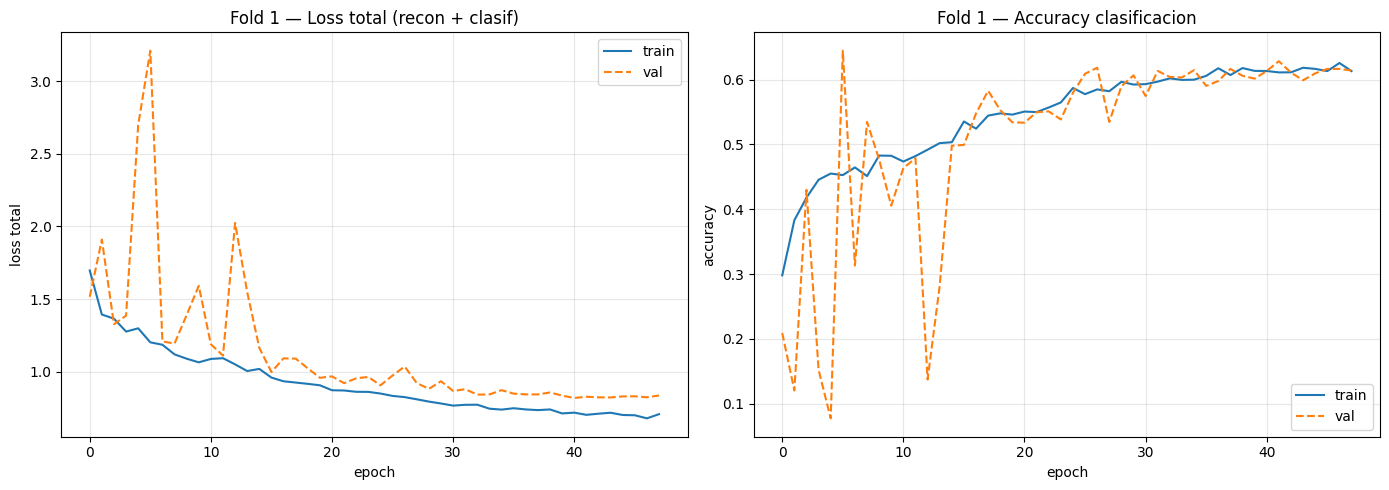


--- Evaluacion sobre test (2003 imgs) ---

--- DISEASE ---
              precision    recall  f1-score   support

       akiec     0.2771    0.6970    0.3966        66
         bcc     0.4275    0.5437    0.4786       103
         bkl     0.4268    0.4795    0.4516       219
          df     0.1008    0.5652    0.1711        23
         mel     0.3366    0.6233    0.4371       223
          nv     0.9566    0.6078    0.7433      1341
        vasc     0.3636    0.8571    0.5106        28

    accuracy                         0.5981      2003
   macro avg     0.4127    0.6248    0.4556      2003
weighted avg     0.7619    0.5981    0.6424      2003



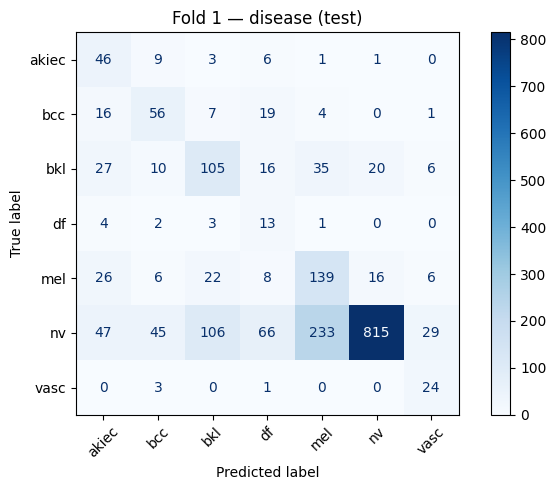

  Pesos guardados en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Disease_experimentos/UNet_STL/exp_2026-06-21_23-15_disease_5fold/fold_1/best_weights

FOLD 2/5  (U-Net disease autoencoder, desde cero)
  train=6409  val=1602  test(fijo)=2003
  Class weights: [ 4.381  2.783  1.301 12.373  1.286  0.213 10.061]

--- Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60) ---
Epoch 1/60
401/401 - 324s - loss: 1.6241 - reconstruction_output_loss: 0.0391 - head_disease_loss: 2.0203 - head_disease_accuracy: 0.2381 - val_loss: 2.6074 - val_reconstruction_output_loss: 0.2405 - val_head_disease_loss: 3.1991 - val_head_disease_accuracy: 0.1548
Epoch 2/60
401/401 - 324s - loss: 1.4068 - reconstruction_output_loss: 0.0143 - head_disease_loss: 1.7549 - head_disease_accuracy: 0.3668 - val_loss: 1.9846 - val_reconstruction_output_loss: 0.0731 - val_head_disease_loss: 2.4625 - val_head_disease_accuracy: 0.1841
Epoch 3/60
401/401 - 322s - loss: 1.3759 - reconstruction_output_loss: 0.0093 - head_disease_lo

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_fold_metrics = []
histories        = []   # UNet: una sola historia por fold (sin warmup+FT separados)

t_exp_start = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(df_trainval)), y_trainval_int), 1):
    fold_dir = EXP_DIR / f"fold_{fold_idx}"
    result   = train_one_fold(fold_idx, train_idx, val_idx, fold_dir)
    all_fold_metrics.append(result["metrics"])
    histories.append(result["history"])
    del result
    tf.keras.backend.clear_session()

t_exp_total = time.time() - t_exp_start

print(f"\n{'='*70}")
print(f"*** Experimento STL UNet disease completo en {t_exp_total/60:.1f} min ***")
print(f"{'='*70}")

df_metrics = pd.DataFrame(all_fold_metrics)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

numeric = [c for c in df_metrics.columns
           if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\n" + "="*70)
print(f"RESUMEN ENTRE {N_FOLDS} FOLDS")
print("="*70)
print(summary[["mean", "median", "std"]])
print(f"\nGuardado en: {EXP_DIR}")

In [ ]:
def _hist_to_dict(h):
    return h.history if hasattr(h, "history") else h

def _pad_to_len(arr, max_len):
    arr = np.asarray(arr, dtype=np.float32)
    out = np.full((max_len,), np.nan, dtype=np.float32)
    out[:min(len(arr), max_len)] = arr[:min(len(arr), max_len)]
    return out

def _stack_metric(histories, key):
    hs      = [_hist_to_dict(h) for h in histories]
    lens    = [len(h.get(key, [])) for h in hs]
    max_len = max(lens) if lens else 0
    if max_len == 0:
        return np.empty((0, 0), dtype=np.float32), 0
    stacked = np.vstack([_pad_to_len(h.get(key, []), max_len)
                         for h in hs]).astype(np.float32)
    return stacked, max_len


plots_dir = EXP_DIR / "training_plots_cv"
plots_dir.mkdir(exist_ok=True)

#Loss + accuracy (mean ± std entre folds)
keys = {"loss": ("loss", "val_loss"), "accuracy": ("head_disease_accuracy", "val_head_disease_accuracy")}
stacked_dict, max_len = {}, 0
for name, (k_tr, k_va) in keys.items():
    tr, ml = _stack_metric(histories, k_tr)
    va, _  = _stack_metric(histories, k_va)
    stacked_dict[name] = (tr, va)
    max_len = max(max_len, ml)
epochs = np.arange(1, max_len + 1)

plt.figure(figsize=(14, 5))
for i, name in enumerate(["loss", "accuracy"], 1):
    tr, va = stacked_dict[name]
    m_tr = np.nanmean(tr, axis=0); s_tr = np.nanstd(tr, axis=0)
    m_va = np.nanmean(va, axis=0); s_va = np.nanstd(va, axis=0)
    plt.subplot(1, 2, i)
    for f in range(tr.shape[0]):
        plt.plot(epochs, tr[f], alpha=0.2, linewidth=1)
    for f in range(va.shape[0]):
        plt.plot(epochs, va[f], alpha=0.2, linewidth=1, linestyle="--")
    plt.plot(epochs, m_tr, linewidth=2, label=f"train {name} mean")
    plt.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=0.2)
    plt.plot(epochs, m_va, linewidth=2, linestyle="--", label=f"val {name} mean")
    plt.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=0.2)
    plt.title(f"STL UNet disease - {name} (mean ± std entre folds)")
    plt.xlabel("epoch"); plt.ylabel(name)
    plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "training_cv_mean_std.png", dpi=300)
plt.show()

In [ ]:
import cv2

#Parámetros 
SEG_MASKS_PATH = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"


best_fold_idx = int(df_metrics["disease_balanced_acc"].idxmax()) + 1
print(f"Usando fold {best_fold_idx}  "
      f"(disease_balanced_acc={df_metrics['disease_balanced_acc'].max():.4f})")

fold_dir_best = EXP_DIR / f"fold_{best_fold_idx}"
weights_path  = fold_dir_best / "best_weights"

#Reconstruir modelo y cargar pesos
backbone_gc, _ = build_model()

# Forward dummy para inicializar
for imgs, _ in test_ds.take(1):
    _ = backbone_gc(imgs[:1], training=False)

if (fold_dir_best / "best_weights.index").exists():
    backbone_gc.load_weights(str(weights_path))
    print(f"Pesos cargados desde {weights_path}")
else:
    print(f"[AVISO] No se encontró {weights_path}.index")


#GradCAM 
def make_gradcam_heatmap(img_array, model, class_idx):
    """
    GradCAM para UNet STL disease (encoder-only).
    Usamos la última Conv2D del bottleneck como capa de activación.
    Cabeza compartida simplificada: Dense(256) + Dropout(0.3).
    """
    # Capa de activacion para Grad-CAM: ultima conv del cuello de botella.
    # OJO: ahora hay decodificador, asi que NO vale "la ultima Conv2D del modelo"
    # (esa seria del decodificador). Usamos la capa nombrada "bottleneck_conv".
    last_conv_layer = "bottleneck_conv"

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.get_layer("head_disease").output,   # salida de clasificacion
        ]
    )

    gap_layer    = model.get_layer("gap")
    shared_dense = model.get_layer("shared_dense")
    shared_drop  = model.get_layer("shared_dropout")
    head_disease = model.get_layer("head_disease")

    with tf.GradientTape() as tape:
        conv_outputs, _ = grad_model(img_array, training=False)
        tape.watch(conv_outputs)

        # Reconstruimos el forward desde gap hasta la cabeza
        # (cabeza compartida simplificada: Dense(256) + Dropout(0.3))
        x     = gap_layer(conv_outputs)
        x     = shared_dense(x)
        x     = shared_drop(x, training=False)
        preds = head_disease(x)
        loss  = preds[:, class_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img_orig, heatmap, alpha=0.45):
    heatmap_r = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
    colored   = cv2.applyColorMap((heatmap_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    colored   = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return (alpha * colored + (1 - alpha) * img_orig).astype(np.uint8)


def load_img_for_gradcam(filepath):
    raw      = tf.io.read_file(filepath)
    raw      = tf.image.decode_image(raw, channels=3, expand_animations=False)
    raw      = tf.image.resize(raw, IMG_SIZE)
    img_orig = raw.numpy().astype(np.uint8)
    img_pre  = tf.cast(raw, tf.float32) / 255.0        # UNet: normalización [0,1]
    return img_orig, tf.expand_dims(img_pre, 0)


def load_lesion_mask(image_id):
    """Carga la máscara binaria de la lesión y la redimensiona a IMG_SIZE."""
    mask_path = os.path.join(SEG_MASKS_PATH, f"{image_id}_segmentation.png")
    if not os.path.exists(mask_path):
        return None
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return mask


#Plot matriz por clase (sin máscaras), disease 
def plot_gradcam_by_class(df_test, y_true_int, y_pred_int, y_pred_proba,
                           backbone_model, class_names,
                           task_name="disease", fold_label="", save_dir=None):
    """Matriz 4 x n_clases (sin máscaras)."""
    n_cls = len(class_names)
    fig, axes = plt.subplots(4, n_cls, figsize=(3 * n_cls, 12))
    if n_cls == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"{fold_label} GradCAM buenas/malas por clase - Tarea: {task_name}",
                 fontsize=13, fontweight="bold", y=0.995)

    for ci, cname in enumerate(class_names):
        #MAL clasificadas 
        mask_bad = (y_true_int == ci) & (y_pred_int != ci)
        idx_bad  = np.where(mask_bad)[0]
        if len(idx_bad) > 0:
            confidences          = y_pred_proba[idx_bad, y_pred_int[idx_bad]]
            best                 = idx_bad[np.argmax(confidences)]
            top2_idx             = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls, top2_cls   = class_names[top2_idx[0]], class_names[top2_idx[1]]
            top1_prob, top2_prob = y_pred_proba[best, top2_idx[0]], y_pred_proba[best, top2_idx[1]]

            filepath          = df_test.iloc[best]["filepath"]
            image_id          = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap           = make_gradcam_heatmap(img_pre, backbone_model,
                                                      class_idx=int(top2_idx[0]))
            overlay           = overlay_heatmap(img_orig, heatmap)

            axes[0, ci].imshow(img_orig)
            axes[0, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="red")
            axes[1, ci].imshow(overlay)
        else:
            axes[0, ci].text(0.5, 0.5, f"{cname}\nNo hay\nmalas",
                             ha="center", va="center", fontsize=8)
            axes[1, ci].text(0.5, 0.5, "-", ha="center", va="center")

        #BIEN clasificadas 
        mask_good = (y_true_int == ci) & (y_pred_int == ci)
        idx_good  = np.where(mask_good)[0]
        if len(idx_good) > 0:
            confidences          = y_pred_proba[idx_good, ci]
            best                 = idx_good[np.argmax(confidences)]
            top2_idx             = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls, top2_cls   = class_names[top2_idx[0]], class_names[top2_idx[1]]
            top1_prob, top2_prob = y_pred_proba[best, top2_idx[0]], y_pred_proba[best, top2_idx[1]]

            filepath          = df_test.iloc[best]["filepath"]
            image_id          = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap           = make_gradcam_heatmap(img_pre, backbone_model,
                                                      class_idx=int(ci))
            overlay           = overlay_heatmap(img_orig, heatmap)

            axes[2, ci].imshow(img_orig)
            axes[2, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="green")
            axes[3, ci].imshow(overlay)
        else:
            axes[2, ci].text(0.5, 0.5, f"{cname}\nNo hay\nbuenas",
                             ha="center", va="center", fontsize=8)
            axes[3, ci].text(0.5, 0.5, "-", ha="center", va="center")

        for r in range(4):
            axes[r, ci].axis("off")

    row_labels = [
        "MAL clasificadas\n(alta confianza)",
        "GradCAM (mal)",
        "BIEN clasificadas\n(alta confianza)",
        "GradCAM (bien)",
    ]
    for r, label in enumerate(row_labels):
        axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                        fontsize=9, rotation=90, va="center", ha="right",
                        fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_dir:
        out = Path(save_dir) / f"gradcam_{task_name}_by_class.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Guardado: {out}")
    plt.show()


#Predicciones del fold elegido 
print("\nRecomputando predicciones del fold seleccionado...")
preds_gc        = backbone_gc.predict(test_ds, verbose=0)
y_pred_proba_gc = preds_gc[1]   # [0]=reconstruccion, [1]=clasificacion
y_pred_int_gc   = np.argmax(y_pred_proba_gc, axis=1)

gradcam_dir = EXP_DIR / "gradcam"
gradcam_dir.mkdir(exist_ok=True)
fold_label  = f"Fold {best_fold_idx}"

#Ejecutar GradCAM para disease 
print("\n=== GradCAM - Tarea: DISEASE (matriz por clase) ===")
plot_gradcam_by_class(
    df_test, y_test_disease_int, y_pred_int_gc, y_pred_proba_gc,
    backbone_gc, class_names=class_names,
    task_name="disease", fold_label=fold_label, save_dir=str(gradcam_dir))

print(f"\n Todas las imágenes GradCAM guardadas en: {gradcam_dir.resolve()}")

In [ ]:
#Matriz de confusión agregada entre folds 
cms = []
for k in range(1, N_FOLDS + 1):
    cm_path = EXP_DIR / f"fold_{k}" / "confusion_matrix_disease.npy"
    if cm_path.exists():
        cms.append(np.load(cm_path))

if cms:
    cm_sum  = np.sum(cms, axis=0)
    cm_norm = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ConfusionMatrixDisplay(cm_sum, display_labels=class_names).plot(
        ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=True, values_format="d")
    axes[0].set_title(f"CM agregada - Disease ({N_FOLDS} folds, conteos)")

    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=True, values_format=".2f")
    axes[1].set_title(f"CM agregada - Disease ({N_FOLDS} folds, normalizada)")

    plt.tight_layout()
    plt.savefig(EXP_DIR / "confusion_matrix_disease_aggregated.png", dpi=120)
    plt.show()
    print(f"\nMatriz agregada guardada en {EXP_DIR}")
else:
    print("[WARN] No se encontraron CMs guardadas.")

In [ ]:
def build_final_pdf():
    pdf_path = EXP_DIR / "FINAL_REPORT_UNet_STL_disease.pdf"

    with PdfPages(pdf_path) as pdf:

        #Portada
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.92, "U-Net completa (codificador + decodificador), entrenada como autoencoder - Reporte final",
                 ha="center", fontsize=20, fontweight="bold")
        fig.text(0.5, 0.87, f"UNet propio  |  K={N_FOLDS} folds  |  Single-task",
                 ha="center", fontsize=13, style="italic")
        fig.text(0.5, 0.83, EXP_DIR.name,
                 ha="center", fontsize=9, family="monospace")

        info  = "Arquitectura: UNet encoder-only (sin ImageNet) + GAP bottleneck + 1 cabeza STL\n\n"
        info += "Encoder: Conv(64) → Conv(128) → Conv(256) → Conv(512)\n"
        info += "Bottleneck: Conv(1024) × 2\n"
        info += "Cabeza compartida: GAP(bottleneck) → Dense(256, relu) → Dropout(0.3)\n"
        info += "  (idéntica a la del MTL UNet final para comparabilidad)\n\n"
        info += "Tarea:\n"
        info += f"  - Disease classification  ({NUM_CLASSES} clases): {', '.join(class_names)}\n\n"
        info += "Configuración de entrenamiento:\n"
        info += f"  - Una sola fase (sin warmup+FT, todo trainable desde inicio)\n"
        info += f"  - LR inicial: {LR_INIT}  |  epochs max: {EPOCHS}\n"
        info += f"  - Early stopping patience: 7  |  ReduceLR patience: 3\n"
        info += f"  - Batch size: {BATCH_SIZE}, image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}\n\n"
        info += f"Loss: categorical_crossentropy\n"
        info += f"Class weights balanceados aplicados a la tarea\n\n"
        info += f"Dataset:\n"
        info += f"  - train+val (CV): {len(df_trainval)} imágenes\n"
        info += f"  - test (fijo):    {len(df_test)} imágenes\n\n"
        info += f"Tiempo total experimento: {t_exp_total/60:.1f} min"

        fig.text(0.08, 0.75, info, fontsize=9, family="monospace", va="top")
        plt.axis("off")
        pdf.savefig(fig); plt.close(fig)

        #Resumen ejecutivo 
        fig, ax = plt.subplots(figsize=(12, 9))
        ax.axis("off")
        ax.set_title(f"Resumen ejecutivo - métricas de clasificación ({N_FOLDS} folds)",
                     fontsize=14, fontweight="bold", pad=20)

        key_metrics = {
            "Disease (7 clases)": [
                ("disease_acc",             "Accuracy"),
                ("disease_balanced_acc",    "Balanced Acc"),
                ("disease_precision_macro", "Precision macro"),
                ("disease_recall_macro",    "Recall macro"),
                ("disease_f1_macro",        "F1 macro"),
                ("disease_auc_macro",       "AUC macro"),
                ("disease_kappa",           "Kappa"),
                ("auc_melanoma",            "AUC melanoma (1-vs-rest)"),
            ],
        }

        rows       = []
        row_colors = []
        for task_title, metrics_list in key_metrics.items():
            rows.append([task_title, "", "", ""])
            row_colors.append(["#d9e1f2"] * 4)
            for metric_key, label in metrics_list:
                if metric_key in summary.index:
                    mean   = summary.loc[metric_key, "mean"]
                    median = summary.loc[metric_key, "median"]
                    std    = summary.loc[metric_key, "std"]
                    rows.append([f"  {label}",
                                 f"{mean:.4f}", f"{median:.4f}", f"{std:.4f}"])
                    row_colors.append(
                        ["#fce4d6"] * 4 if metric_key == "auc_melanoma"
                        else ["white"] * 4)

        tbl = ax.table(
            cellText=rows,
            colLabels=["Métrica", "Media", "Mediana", "Desv. típica"],
            loc="center", cellLoc="left",
            cellColours=row_colors,
            colColours=["#305496"] * 4,
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
        for j in range(4):
            tbl[(0, j)].set_text_props(color="white", fontweight="bold")
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #Tabla completa mean/median/std 
        fig, ax = plt.subplots(figsize=(13, 8.5))
        ax.axis("off")
        ax.set_title(f"Resumen completo entre folds (K={N_FOLDS}) - mean / median / std",
                     fontsize=14, fontweight="bold", pad=20)
        tbl = ax.table(
            cellText=[[i, f"{r['mean']:.4f}", f"{r['median']:.4f}", f"{r['std']:.4f}"]
                      for i, r in summary.iterrows()],
            colLabels=["métrica", "mean", "median", "std"],
            loc="center", cellLoc="left",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Tabla métricas por fold 
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis("off")
        ax.set_title("Métricas por fold - Disease",
                     fontsize=14, fontweight="bold", pad=20)
        cols = [
            "fold",
            "disease_acc", "disease_balanced_acc",
            "disease_precision_macro", "disease_recall_macro",
            "disease_f1_macro", "disease_auc_macro", "disease_kappa",
            "auc_melanoma",
            "epochs_trained", "time_train_s",
        ]
        df_show = df_metrics[[c for c in cols if c in df_metrics.columns]].copy()
        for c in df_show.columns:
            if c != "fold":
                df_show[c] = df_show[c].round(4)
        tbl = ax.table(
            cellText=df_show.values.tolist(),
            colLabels=df_show.columns.tolist(),
            loc="center", cellLoc="center",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Curvas de entrenamiento 
        for fname, title in [
            ("training_cv_mean_std.png", "Loss/Acc total (mean ± std)"),
        ]:
            p = plots_dir / fname
            if p.exists():
                fig = plt.figure(figsize=(14, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(title, fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

        #Detalle por fold 
        for k in range(1, N_FOLDS + 1):
            fd = EXP_DIR / f"fold_{k}"

            # Curvas de entrenamiento del fold (loss + accuracy)
            p = fd / "training_curves.png"
            if p.exists():
                fig = plt.figure(figsize=(14, 6))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Curvas de entrenamiento",
                          fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            # Matriz de confusión disease
            p = fd / "confusion_matrix_disease.png"
            if p.exists():
                fig = plt.figure(figsize=(10, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Matriz confusión - Disease (7 clases)",
                          fontsize=11, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            # Classification report disease
            rpt = fd / "classification_report_disease.txt"
            if rpt.exists():
                fig = plt.figure(figsize=(11, 8.5)); plt.axis("off")
                plt.title(f"Fold {k} - Classification report - Disease",
                          fontsize=11, fontweight="bold", loc="left")
                plt.text(0.05, 0.95, rpt.read_text(),
                         fontsize=10, family="monospace", va="top")
                pdf.savefig(fig); plt.close(fig)

        #Matriz de confusión agregada 
        p = EXP_DIR / "confusion_matrix_disease_aggregated.png"
        if p.exists():
            fig = plt.figure(figsize=(14, 6))
            plt.imshow(plt.imread(str(p))); plt.axis("off")
            plt.title(f"Matriz de confusión agregada - Disease (7 clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #GradCAM por clase 
        p = gradcam_dir / f"gradcam_disease_by_class.png"
        if p.exists():
            img_data = plt.imread(str(p))
            h, w     = img_data.shape[:2]
            fig = plt.figure(figsize=(11, 11 * h / w))
            plt.imshow(img_data); plt.axis("off")
            plt.title(f"GradCAM buenas/malas por clase - Disease (7 clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

    print(f" PDF guardado en: {pdf_path.resolve()}")
    return pdf_path


_ = build_final_pdf()